<p align="left">
  <img src="https://miro.medium.com/v2/resize:fit:1358/1*bSLNlG7crv-p-m4LVYYk3Q.png" width="360" style="display:inline-block;"/>
</p>

# Detecção de Bandeiras de Países com YOLOv8

Este notebook realiza a detecção de **86 bandeiras nacionais** usando YOLOv8s.

Fluxo completo:
1. Upload do dataset limpo (formato YOLOv8) direto no Colab
2. Treinamento de 60 épocas com `yolov8s.pt`
3. Avaliação de métricas (mAP@0.5, Precisão, Recall)
4. Predição em **fotos reais capturadas pelo grupo**

# Pacotes

Instala o pacote `ultralytics` (inclui YOLOv8) e verifica o ambiente Colab.

In [1]:
# Instala o Ultralytics (inclui YOLOv8) — normalmente já disponível no Colab
!pip install ultralytics --quiet

import ultralytics
ultralytics.checks()   # exibe versão, GPU disponível, etc.

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [2]:
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Sobre o Dataset: Country Flags Detection

Dataset obtido via [Roboflow Universe](https://universe.roboflow.com/phamdata/country-flags-2t33e/dataset/4).

## Divisao dos dados (apos limpeza):
- **Total de imagens:** 10.187
  - Treino : 8.940 imagens
  - Validacao: 827 imagens
  - Teste : 420 imagens

## Classes detectadas: **86 bandeiras nacionais**
De Algeria ate Zambia (Afghanistan e Albania foram removidas por anotacoes invalidas).

## Licenca: CC BY 4.0

## Upload do Dataset no Colab

Faca o upload do arquivo **`dataset_clean.zip`** quando solicitado.

> O dataset limpo ja vem com `data.yaml` corrigido e classes reindexadas (0..85).

In [3]:
from google.colab import files
import zipfile

# Aguarda o usuario selecionar o arquivo dataset_clean.zip
print("Selecione o arquivo dataset_clean.zip para upload...")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print(f"Arquivo recebido: {zip_name}")

# Extrai para /content/dataset
os.makedirs('/content/dataset', exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset')
print("Dataset extraido em /content/dataset/")

# Contagem rapida por split
for split in ['train', 'valid', 'test']:
    img_dir = f'/content/dataset/{split}/images'
    lbl_dir = f'/content/dataset/{split}/labels'
    if os.path.isdir(img_dir):
        n_imgs = len([f for f in os.listdir(img_dir)
                      if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        n_lbls = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
        print(f"  {split:6s}: {n_imgs:5d} imagens | {n_lbls:5d} labels")

Selecione o arquivo dataset_clean.zip para upload...


Saving dataset_clean.zip to dataset_clean.zip
Arquivo recebido: dataset_clean.zip
Dataset extraido em /content/dataset/
  train :  8940 imagens |  8940 labels
  valid :   827 imagens |   827 labels
  test  :   420 imagens |   420 labels


## Configuracao do `data.yaml`

A celula abaixo reescreve o `data.yaml` com caminhos absolutos do Colab,
garantindo que o treinamento encontre as imagens corretamente.

In [4]:
import yaml

# Caminhos absolutos para o ambiente Colab
data_yaml = {
    'train': '/content/dataset/train/images',
    'val'  : '/content/dataset/valid/images',
    'test' : '/content/dataset/test/images',
    'nc'   : 86,
    'names': ["Algeria Flag", "American Samoa", "Andorra Flag", "Angola Flag", "Anguilla Flag", "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Bahrain", "Belgium", "Bolivia", "Bosnia and Herzegovina", "Brazil", "Cameroon", "Canada", "Cape Verde", "Chile", "China", "Colombia", "Costa Rica", "Croatia", "Czech Republic", "Democratic Republic of the Congo", "Denmark", "Ecuador", "Egypt", "El Salvador", "England", "Finland", "France", "Gabon", "Georgia", "Germany", "Ghana", "Greece", "Haiti", "Honduras", "Hungary", "Iceland", "Iran", "Iraq", "Israel", "Italy", "Ivory Coast", "Jamaica", "Japan", "Jordan", "Madagascar", "Mali", "Mexico", "Morocco", "Netherlands", "New Zealand", "Nigeria", "Norway", "Panama", "Paraguay", "Peru", "Poland", "Portugal", "Romania", "Saudi Arabia", "Scotland", "Senegal", "Serbia", "Slovakia", "Slovenia", "South Africa", "South Korea", "Spain", "Sweden", "Switzerland", "Tanzania", "Tunisia", "Turkey", "Ukraine", "United Arab Emirates", "United States", "Uruguay", "Uzbekistan", "Venezuela", "Vietnam", "Wales", "Zambia"],
}

yaml_path = '/content/dataset/data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("data.yaml configurado:")
with open(yaml_path) as f:
    print(f.read()[:400], "...")  # mostra o inicio

data.yaml configurado:
train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images
nc: 86
names:
- Algeria Flag
- American Samoa
- Andorra Flag
- Angola Flag
- Anguilla Flag
- Antigua and Barbuda
- Argentina
- Armenia
- Australia
- Austria
- Bahrain
- Belgium
- Bolivia
- Bosnia and Herzegovina
- Brazil
- Cameroon
- Canada
- Cape Verde
- Chile
- China
- Colombia
- Costa Rica ...


In [5]:
# Lista de nomes das 86 classes (mesma ordem do data.yaml)
nomes_classes = ['Algeria Flag', 'American Samoa', 'Andorra Flag', 'Angola Flag', 'Anguilla Flag', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Bahrain', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Cameroon', 'Canada', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Democratic Republic of the Congo', 'Denmark', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Iran', 'Iraq', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Jordan', 'Madagascar', 'Mali', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Romania', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Tanzania', 'Tunisia', 'Turkey', 'Ukraine', 'United Arab Emirates', 'United States', 'Uruguay', 'Uzbekistan', 'Venezuela', 'Vietnam', 'Wales', 'Zambia']

print(f"Total de classes: {len(nomes_classes)}")
print("Primeiras 5:", nomes_classes[:5])
print("Ultimas  5:", nomes_classes[-5:])

Total de classes: 86
Primeiras 5: ['Algeria Flag', 'American Samoa', 'Andorra Flag', 'Angola Flag', 'Anguilla Flag']
Ultimas  5: ['Uzbekistan', 'Venezuela', 'Vietnam', 'Wales', 'Zambia']


## Visualizacao de Amostras (Test Set)

Exibe 4 imagens aleatorias do conjunto de teste com suas bounding boxes.

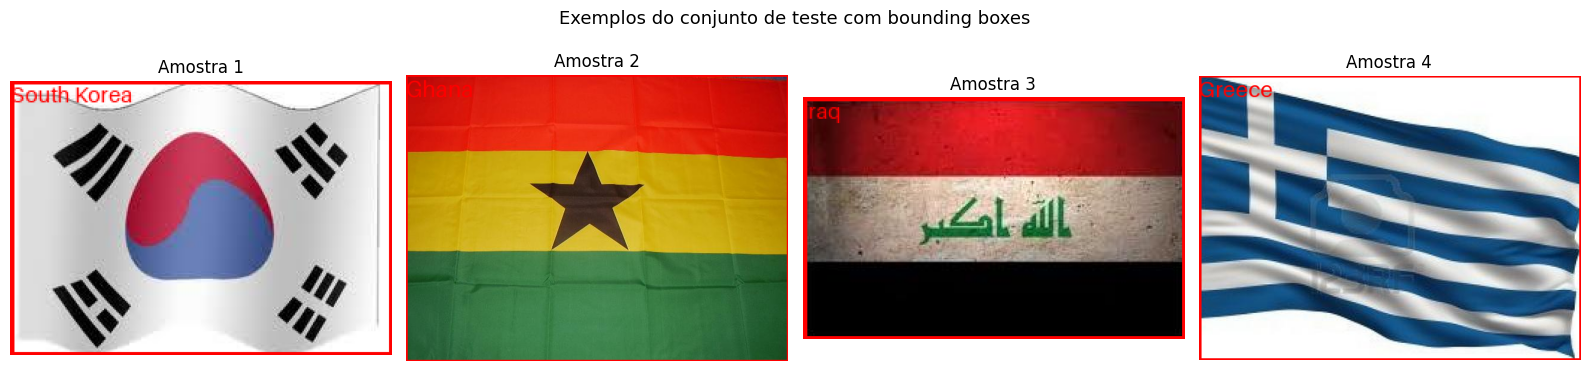

In [6]:
# Diretórios do conjunto de teste
test_img_dir = '/content/dataset/test/images'
test_lbl_dir = '/content/dataset/test/labels'

# Seleciona 4 imagens aleatorias
image_files = [f for f in os.listdir(test_img_dir)
               if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
sample_images = random.sample(image_files, min(4, len(image_files)))

plt.figure(figsize=(16, 4))

for i, img_file in enumerate(sample_images):
    img_path = os.path.join(test_img_dir, img_file)
    lbl_path = os.path.join(test_lbl_dir, os.path.splitext(img_file)[0] + '.txt')

    img = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font_size = max(int(w * 0.06), 12)

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                x2 = (xc + bw / 2) * w
                y2 = (yc + bh / 2) * h
                draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
                nome = nomes_classes[cls_id] if cls_id < len(nomes_classes) else f'Classe {cls_id}'
                draw.text((x1, max(y1 - font_size, 0)), nome, fill='red', font_size=font_size)

    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Amostra {i + 1}')

plt.suptitle('Exemplos do conjunto de teste com bounding boxes', fontsize=13)
plt.tight_layout()
plt.show()

## Estrutura esperada do dataset (YOLOv8)

```
dataset/
├── train/
│   ├── images/   ← imagens de treino
│   └── labels/   ← arquivos .txt com bounding boxes
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml     ← configuracao do dataset
```

# Treinamento do Modelo YOLO

## Escolha do Modelo

Usamos **YOLOv8s** (small) — bom equilibrio entre velocidade e precisao para 86 classes.

| Variante | Parametros | GFLOPs | Notas                          |
|----------|-----------|--------|-------------------------------|
| n (nano) | 3.2 M     | 8.7    | Muito rapido, menos preciso   |
| **s (small)** | **11.2 M** | **28.6** | **Nosso padrao** |
| m (medium) | 25.9 M  | 78.9   | Mais preciso, 2x mais lento   |
| l (large) | 43.7 M   | 165    | Alta precisao, GPU potente    |
| x (extra) | 68.2 M   | 258    | Maximo desempenho             |

Documentacao completa de parametros: https://docs.ultralytics.com/pt/modes/train/

In [7]:
import gc
import torch
from ultralytics import YOLO

# Libera memoria da GPU antes de comecar
gc.collect()
torch.cuda.empty_cache()

# Carrega o modelo pre-treinado YOLOv8s
# Na primeira execucao o Colab baixa automaticamente os pesos do COCO
model = YOLO('yolov8s.pt')

# Inicia o treinamento
# - epochs=60: suficiente para convergir com 86 classes
# - imgsz=640: resolucao padrao YOLOv8 (boa para detalhes de bandeiras)
# - batch=16 : cabe na GPU T4 do Colab (16 GB VRAM)
#              se der OOM, reduza para 8 ou use batch=-1 (autobatch)
# - patience=15: para antecipadamente se nao houver melhora por 15 epocas
model.train(
    data='/content/dataset/data.yaml',
    epochs=60,
    imgsz=640,
    batch=16,
    patience=15,
    project='runs/detect',
    name='bandeiras',
    exist_ok=True,
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bandeiras, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79, 80, 81, 82, 83, 84, 85])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7828cf2adaf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0

> **Nota:** Nao e preciso recarregar o modelo se voce acabou de treinar.
> A variavel `model` ja aponta para os melhores pesos.
> O bloco abaixo so e necessario se voce reabrir o notebook apos o treino.

In [8]:
# Descomente para carregar o modelo ja treinado (util ao reabrir o notebook)
# model = YOLO('runs/detect/bandeiras/weights/best.pt')
# print("Modelo carregado:", model.info())

## Visualizacao do Batch de Treino (Data Augmentation)

O YOLO aplica augmentations automaticamente durante o treino
(flips, HSV jitter, mosaico, etc.).
A imagem abaixo mostra um batch real com essas transformacoes.

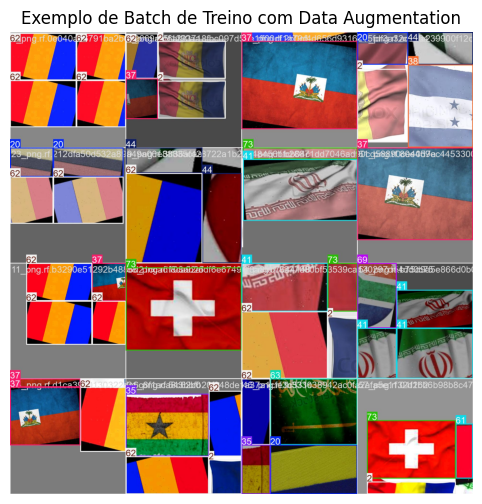

In [9]:
# Detecta a pasta do ultimo treino (evita erros com train2, train3...)
try:
    aug_dir = model.trainer.save_dir
except AttributeError:
    aug_dir = 'runs/detect/bandeiras'

aug_img_path = os.path.join(aug_dir, 'train_batch0.jpg')

if os.path.exists(aug_img_path):
    img = Image.open(aug_img_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Exemplo de Batch de Treino com Data Augmentation')
    plt.show()
else:
    print(f"Imagem nao encontrada em '{aug_img_path}'.")
    print("Isso e normal se voce pulou o treinamento e carregou best.pt diretamente.")

# Avaliacao do Modelo

In [10]:
# Avalia o modelo no conjunto de TESTE (nao visto durante o treino)
results = model.val(data='/content/dataset/data.yaml', split='test')

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,158,866 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 333.9±167.0 MB/s, size: 12.1 KB)
val: Scanning /content/dataset/test/labels... 420 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 420/420 2.0Kit/s 0.2s
val: /content/dataset/test/images/83_png.rf.09631ae4f55bf915889c3653a23abf4d.jpg: 1 duplicate labels removed
val: New cache created: /content/dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 413. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 4.2it/s 6.5s
                   all        420        413      0.968      0.

In [11]:
# Exibe as principais metricas de desempenho
metrics = results.results_dict
print("=" * 45)
print(f"  Precisao media  : {metrics.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall medio    : {metrics.get('metrics/recall(B)', 0):.4f}")
print(f"  mAP@0.5         : {metrics.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP@0.5:0.95    : {metrics.get('metrics/mAP50-95(B)', 0):.4f}")
print("=" * 45)

  Precisao media  : 0.9682
  Recall medio    : 0.9642
  mAP@0.5         : 0.9844
  mAP@0.5:0.95    : 0.9742


## Graficos de Treinamento e Matriz de Confusao

O YOLO salva automaticamente os graficos de treino e a matriz de confusao
na pasta do treinamento. As celulas abaixo exibem essas imagens
(use-as no relatorio tecnico).

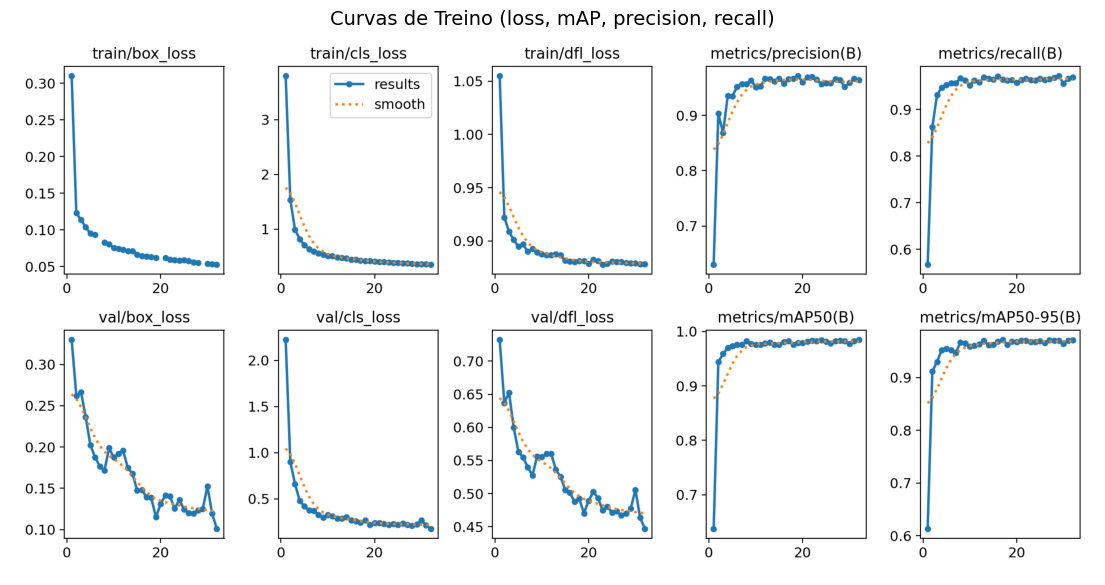

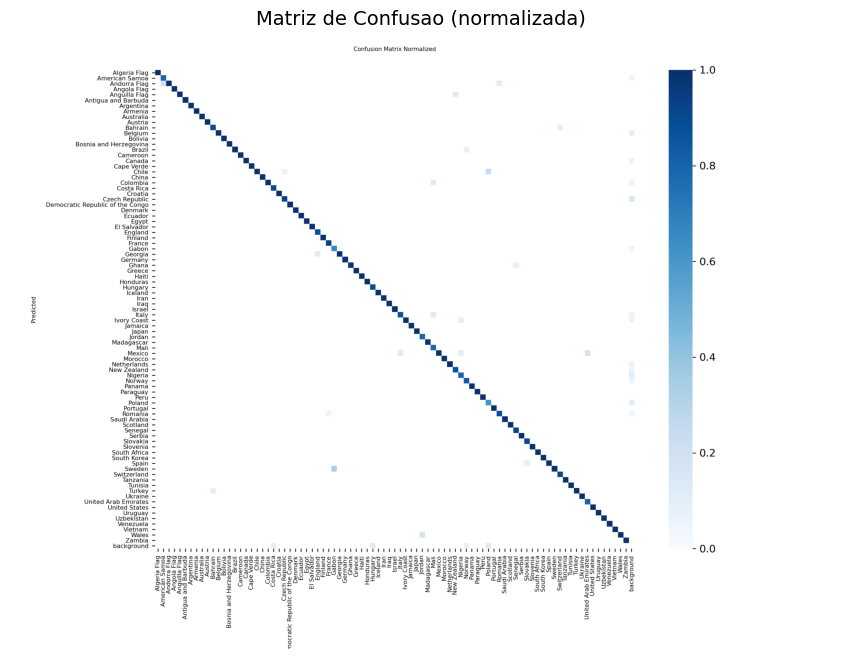

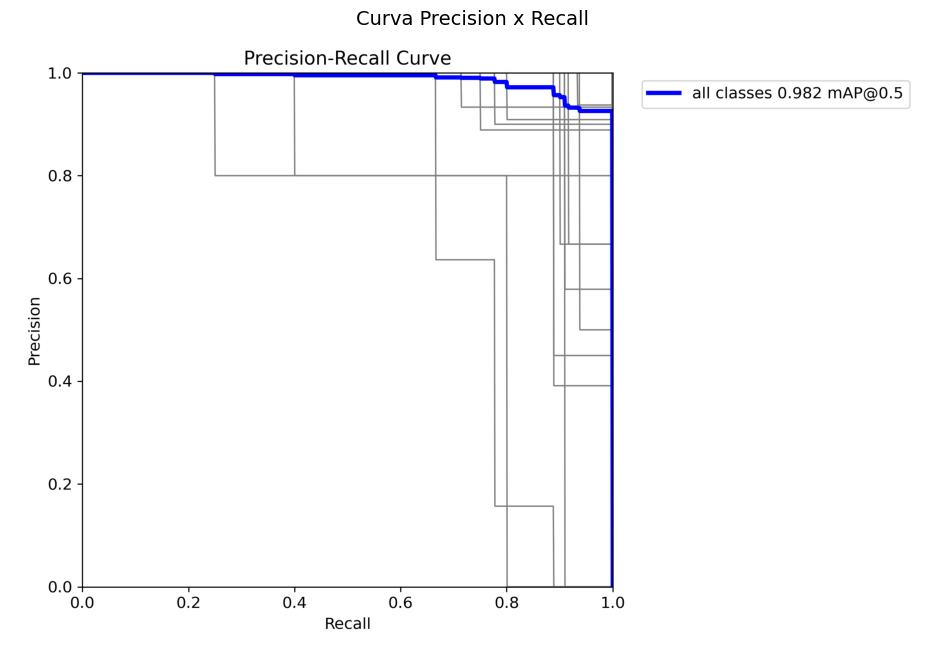

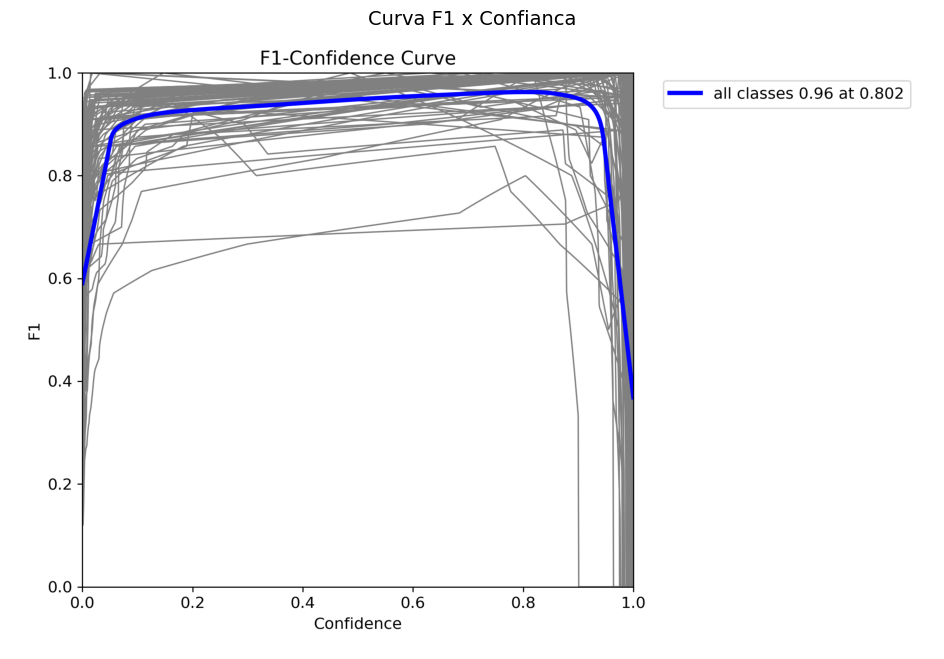

In [12]:
# Pasta onde o YOLO salvou os artefatos do treino
try:
    run_dir = model.trainer.save_dir
except AttributeError:
    run_dir = 'runs/detect/bandeiras'

# Lista de artefatos uteis para o relatorio
artefatos = {
    'results.png'                  : 'Curvas de Treino (loss, mAP, precision, recall)',
    'confusion_matrix_normalized.png': 'Matriz de Confusao (normalizada)',
    'BoxPR_curve.png'              : 'Curva Precision x Recall',
    'BoxF1_curve.png'              : 'Curva F1 x Confianca',
}

for arquivo, titulo in artefatos.items():
    caminho = os.path.join(run_dir, arquivo)
    if os.path.exists(caminho):
        img = Image.open(caminho)
        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(titulo, fontsize=14)
        plt.show()
    else:
        print(f"Nao encontrado: {caminho}")

## Inferencia no Conjunto de Teste

Alem das fotos do grupo, o enunciado pede inferencias nas imagens do
conjunto de teste. Aqui o modelo PREVE (nao usa o gabarito) em 4 imagens
aleatorias do test set.

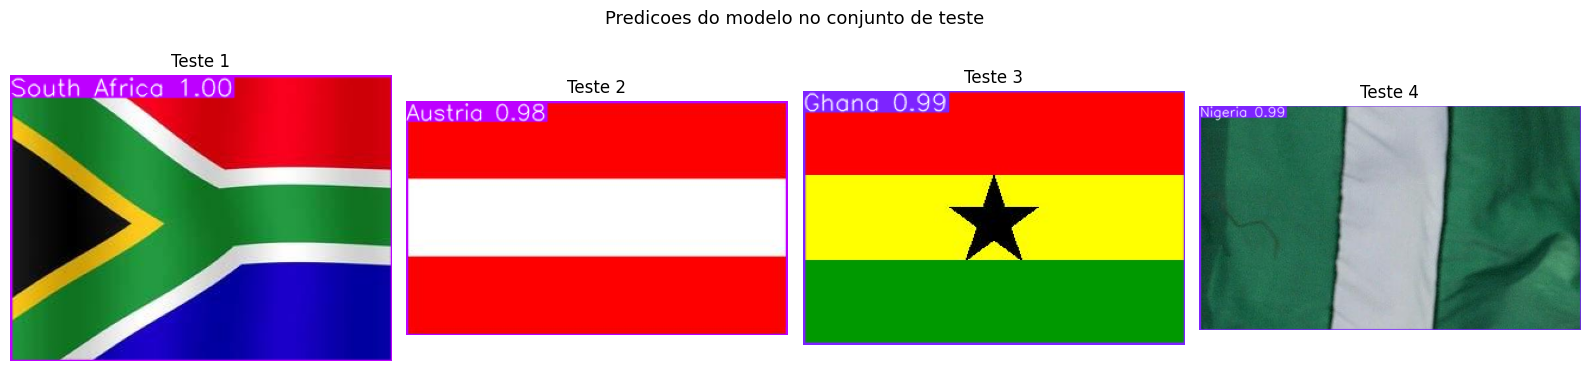

In [13]:
# Seleciona 4 imagens aleatorias do conjunto de teste
test_imgs = glob.glob('/content/dataset/test/images/*.jpg')
amostra = random.sample(test_imgs, min(4, len(test_imgs)))

# Predicao do modelo (sem olhar os labels reais)
preds_test = [model.predict(p, conf=0.25, verbose=False)[0] for p in amostra]

plt.figure(figsize=(16, 4))
for i, pred in enumerate(preds_test):
    img_rgb = pred.plot()[:, :, ::-1]   # BGR -> RGB
    plt.subplot(1, 4, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Teste {i + 1}')
plt.suptitle('Predicoes do modelo no conjunto de teste', fontsize=13)
plt.tight_layout()
plt.show()

# Predicao nas Fotos Capturadas pelo Grupo

Aqui voce fara upload das **fotos reais de bandeiras** tiradas pelo grupo.

> Requisito do enunciado: as imagens devem ser **capturadas pelo proprio grupo**,
> nao baixadas da internet.

## Upload das Fotos Reais

Clique em "Escolher arquivos" e selecione as fotos de bandeiras capturadas pelo grupo.
Formatos aceitos: `.jpg`, `.jpeg`, `.png`

In [20]:
from google.colab import files

# Upload das fotos reais de bandeiras capturadas pelo grupo
print("Envie as fotos de bandeiras capturadas pelo grupo:")
uploaded_fotos = files.upload()

# Lista de caminhos das imagens enviadas
image_paths = list(uploaded_fotos.keys())
print(f"\n{len(image_paths)} imagem(ns) carregada(s):")
for p in image_paths:
    print(f"  - {p}")

Envie as fotos de bandeiras capturadas pelo grupo:


Saving usa.png to usa (1).png

1 imagem(ns) carregada(s):
  - usa (1).png


## Resultado das Deteccoes

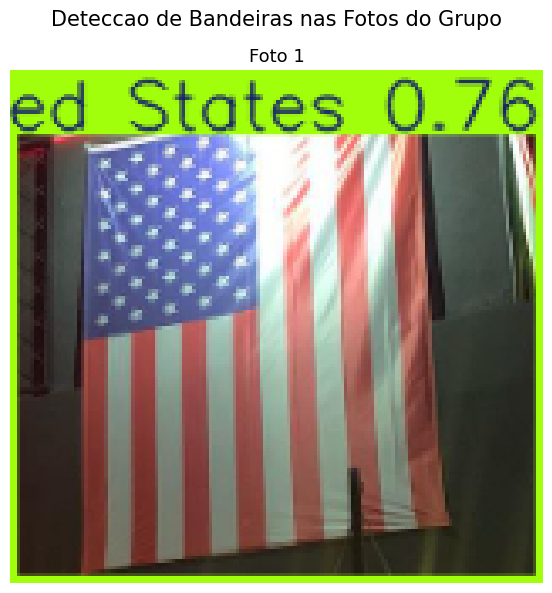

In [21]:
# Realiza a predicao em todas as imagens enviadas
# conf=0.25: confianca minima para exibir uma deteccao
preds = [model.predict(img_path, conf=0.25, verbose=False)[0] for img_path in image_paths]

# Plota as imagens com bounding boxes desenhadas pelo proprio YOLO
n = len(preds)
plt.figure(figsize=(7 * n, 6))

for i, pred in enumerate(preds):
    # .plot() retorna array BGR com caixas, labels e confiancas sobrepostos
    img_bgr = pred.plot()
    img_rgb = img_bgr[:, :, ::-1]   # BGR -> RGB para o matplotlib

    plt.subplot(1, n, i + 1)
    plt.imshow(img_rgb)
    plt.title(f'Foto {i + 1}', fontsize=13)
    plt.axis('off')

plt.suptitle('Deteccao de Bandeiras nas Fotos do Grupo', fontsize=15)
plt.tight_layout()
plt.show()

In [22]:
# Exibe os detalhes textuais de cada deteccao (classe, confianca, bbox)
for i, (pred, path) in enumerate(zip(preds, image_paths)):
    print(f"\nFoto {i + 1}: {path}")
    if len(pred.boxes) == 0:
        print("  Nenhuma bandeira detectada.")
        print("  Dica: diminua conf=0.25 para conf=0.10 na celula acima e execute de novo.")
        continue
    for box in pred.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        nome   = nomes_classes[cls_id] if cls_id < len(nomes_classes) else f'Classe {cls_id}'
        # Coordenadas absolutas da bbox
        x1, y1, x2, y2 = [round(v, 1) for v in box.xyxy[0].tolist()]
        print(f"  [{conf:.1%}] {nome}  bbox=({x1},{y1},{x2},{y2})")


Foto 1: usa (1).png
  [76.2%] United States  bbox=(0.0,0.0,157.9,151.8)
